In [1]:
from sklearn.impute import SimpleImputer

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Creating DataFrame
exoplanet_df = pd.read_csv('planetsdata.csv')

In [4]:
print(exoplanet_df.head())

                  P_NAME   P_DETECTION P_DISCOVERY_FACILITY  P_YEAR  \
0  OGLE-2016-BLG-1227L b  Microlensing                 OGLE    2020   
1           Kepler-276 c       Transit               Kepler    2013   
2           Kepler-829 b       Transit               Kepler    2016   
3               K2-283 b       Transit                   K2    2018   
4           Kepler-477 b       Transit               Kepler    2016   

     P_UPDATE  P_MASS  P_MASS_ERROR_MIN  P_MASS_ERROR_MAX  P_MASS_LIMIT  \
0  2020-04-02  250.00            -120.0             413.0             0   
1  2018-09-25   16.60              -3.6               4.4             0   
2  2019-04-16    5.10               NaN               NaN             0   
3  2019-09-05   12.20               NaN               NaN             0   
4  2019-04-16    4.94               NaN               NaN             0   

      P_MASS_ORIGIN  ...  S_ABIO_ZONE  S_TIDAL_LOCK  P_HABZONE_OPT  \
0              Mass  ...          NaN      0.214133 

In [5]:
exoplanet_df.columns

Index(['P_NAME', 'P_DETECTION', 'P_DISCOVERY_FACILITY', 'P_YEAR', 'P_UPDATE',
       'P_MASS', 'P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT',
       'P_MASS_ORIGIN',
       ...
       'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON',
       'P_TYPE_TEMP', 'P_HABITABLE', 'P_ESI', 'S_CONSTELLATION',
       'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG'],
      dtype='object', length=118)

In [6]:
exoplanet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5569 entries, 0 to 5568
Columns: 118 entries, P_NAME to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(19)
memory usage: 5.0+ MB


In [7]:
#Dropping Uncertainity Columns
cols_to_drop = [col for col in exoplanet_df.columns if '_ERROR_MIN' in col or '_ERROR_MAX' in col or '_LIMIT' in col]
print(cols_to_drop)

['P_MASS_ERROR_MIN', 'P_MASS_ERROR_MAX', 'P_MASS_LIMIT', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_RADIUS_LIMIT', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'P_PERIOD_LIMIT', 'P_SEMI_MAJOR_AXIS_ERROR_MIN', 'P_SEMI_MAJOR_AXIS_ERROR_MAX', 'P_SEMI_MAJOR_AXIS_LIMIT', 'P_ECCENTRICITY_ERROR_MIN', 'P_ECCENTRICITY_ERROR_MAX', 'P_ECCENTRICITY_LIMIT', 'P_INCLINATION_ERROR_MIN', 'P_INCLINATION_ERROR_MAX', 'P_INCLINATION_LIMIT', 'P_OMEGA_ERROR_MIN', 'P_OMEGA_ERROR_MAX', 'P_OMEGA_LIMIT', 'S_MAG_ERROR_MIN', 'S_MAG_ERROR_MAX', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_TEMPERATURE_LIMIT', 'S_MASS_ERROR_MIN', 'S_MASS_ERROR_MAX', 'S_MASS_LIMIT', 'S_RADIUS_ERROR_MIN', 'S_RADIUS_ERROR_MAX', 'S_RADIUS_LIMIT', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_METALLICITY_LIMIT', 'S_AGE_ERROR_MIN', 'S_AGE_ERROR_MAX', 'S_AGE_LIMIT', 'S_LOG_LUM_ERROR_MIN', 'S_LOG_LUM_ERROR_MAX', 'S_LOG_LUM_LIMIT', 'S_LOG_G_ERROR_MIN', 'S_LOG_G_ERROR_MA

In [8]:
exoplanet_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [9]:
print(exoplanet_df.count().to_string())

P_NAME                  5569
P_DETECTION             5569
P_DISCOVERY_FACILITY    5569
P_YEAR                  5569
P_UPDATE                5569
P_MASS                  5562
P_MASS_ORIGIN           5569
P_RADIUS                5562
P_PERIOD                5323
P_SEMI_MAJOR_AXIS       5565
P_ECCENTRICITY          4794
P_INCLINATION           4268
P_OMEGA                 1639
S_NAME                  5569
S_NAME_HD                966
S_NAME_HIP              1015
S_TYPE                  2006
S_RA                    5569
S_DEC                   5569
S_RA_STR                5569
S_DEC_STR               5569
S_MAG                   5353
S_DISTANCE              5548
S_TEMPERATURE           5353
S_MASS                  5565
S_RADIUS                5340
S_METALLICITY           5140
S_AGE                   4365
S_LOG_LUM               5337
S_LOG_G                 5326
P_ESCAPE                5562
P_POTENTIAL             5562
P_GRAVITY               5562
P_DENSITY               5562
P_HILL_SPHERE 

In [10]:
# Calculate null values per column
null_values = exoplanet_df.isnull().sum()

# Print the full list
print(null_values.to_string())

P_NAME                     0
P_DETECTION                0
P_DISCOVERY_FACILITY       0
P_YEAR                     0
P_UPDATE                   0
P_MASS                     7
P_MASS_ORIGIN              0
P_RADIUS                   7
P_PERIOD                 246
P_SEMI_MAJOR_AXIS          4
P_ECCENTRICITY           775
P_INCLINATION           1301
P_OMEGA                 3930
S_NAME                     0
S_NAME_HD               4603
S_NAME_HIP              4554
S_TYPE                  3563
S_RA                       0
S_DEC                      0
S_RA_STR                   0
S_DEC_STR                  0
S_MAG                    216
S_DISTANCE                21
S_TEMPERATURE            216
S_MASS                     4
S_RADIUS                 229
S_METALLICITY            429
S_AGE                   1204
S_LOG_LUM                232
S_LOG_G                  243
P_ESCAPE                   7
P_POTENTIAL                7
P_GRAVITY                  7
P_DENSITY                  7
P_HILL_SPHERE 

In [11]:
missing_percentages = exoplanet_df.isnull().mean() * 100

# Identify columns with more than 40% missing values
columns_with_nulls = missing_percentages[missing_percentages > 40].index.tolist()

In [12]:
print(columns_with_nulls)

['P_OMEGA', 'S_NAME_HD', 'S_NAME_HIP', 'S_TYPE', 'P_TEMP_SURF']


In [13]:
#delete some unnecessary and null columns
unnecessary_columns=["P_NAME", "P_DETECTION", "P_DISCOVERY_FACILITY", "P_UPDATE", "P_YEAR", "S_NAME_HD", "S_NAME_HIP","P_OMEGA","S_NAME"]
exoplanet_df = exoplanet_df.drop(columns=unnecessary_columns)

In [14]:
#drop P_ESI as it leaks information about habitibility
exoplanet_df = exoplanet_df.drop(columns="P_ESI")

In [15]:
# Create the temporary average column
exoplanet_df['P_TEMP_SURF_AVG'] = (exoplanet_df['P_TEMP_SURF_MIN'] + exoplanet_df['P_TEMP_SURF_MAX']) / 2

# Fix the nulls of P_TEMP_SURF
exoplanet_df['P_TEMP_SURF'] = exoplanet_df['P_TEMP_SURF'].fillna(exoplanet_df['P_TEMP_SURF_AVG'])

# Clean up the temporary column
exoplanet_df.drop(columns=['P_TEMP_SURF_AVG'], inplace=True, errors='ignore')

In [16]:
def derive_detailed_star_type(temp):
    """Maps stellar temperature to the precise MK/Brown Dwarf classification."""
    if pd.isna(temp):
        # This will return 'Unknown' for rows where S_TEMPERATURE is null,
        # preserving the missing status for later row dropping.
        return None 
    
    # O, B, A, F, G, K, M Types
    if temp > 30000:
        return 'O-Type'
    if temp > 10000:
        return 'B-Type'
    if temp > 7500:
        return 'A-Type'
    if temp > 6000:
        return 'F-Type'
    if temp > 5000:
        return 'G-Type' # Sun-like
    if temp > 3500:
        return 'K-Type'
    if temp > 2500: 
        return 'M-Type'
        
    # Brown Dwarfs (L, T, Y Types)
    if temp > 1500:
        return 'L-Type' # Brown Dwarf
    if temp > 800:
        return 'T-Type' # Brown Dwarf
    if temp <= 800:
        return 'Y-Type' # Brown Dwarf
    
    return 'Unclassified'

In [17]:
# Create the new column by applying the precise physical mapping function and where S_TEMPERATURE was NaN will now have 'Unknown' in this new column.
exoplanet_df['Derived_S_TYPE'] = exoplanet_df['S_TEMPERATURE'].apply(derive_detailed_star_type)

In [18]:
# Drop the original S_TYPE column (the one with ~64% missing values)
exoplanet_df.drop(columns=['S_TYPE'], inplace=True, errors='ignore')

In [30]:
exoplanet_df.shape

(5569, 62)

In [19]:
missing_values = exoplanet_df.isnull().sum()
missing_values = missing_values[missing_values > 0]

In [20]:
print(missing_values)

P_MASS                  7
P_RADIUS                7
P_PERIOD              246
P_SEMI_MAJOR_AXIS       4
P_ECCENTRICITY        775
P_INCLINATION        1301
S_MAG                 216
S_DISTANCE             21
S_TEMPERATURE         216
S_MASS                  4
S_RADIUS              229
S_METALLICITY         429
S_AGE                1204
S_LOG_LUM             232
S_LOG_G               243
P_ESCAPE                7
P_POTENTIAL             7
P_GRAVITY               7
P_DENSITY               7
P_HILL_SPHERE          12
P_DISTANCE              4
P_PERIASTRON            4
P_APASTRON              4
P_DISTANCE_EFF          4
P_FLUX                231
P_FLUX_MIN            231
P_FLUX_MAX            231
P_TEMP_EQUIL          231
P_TEMP_EQUIL_MIN      231
P_TEMP_EQUIL_MAX      231
P_TEMP_SURF           231
P_TEMP_SURF_MIN       231
P_TEMP_SURF_MAX       231
P_TYPE                  7
S_TYPE_TEMP           191
S_LUMINOSITY          230
S_HZ_OPT_MIN          230
S_HZ_OPT_MAX          230
S_HZ_CON_MIN

In [21]:
# Count missing values as a percentage of total values
missing_percentage = (exoplanet_df.isnull().sum() / len(exoplanet_df)) * 100
missing_percentage = missing_percentage[missing_percentage > 30]

# Display the result
print(missing_percentage)

Series([], dtype: float64)


In [22]:
# Separate numerical and categorical columns
numerical_cols = exoplanet_df.select_dtypes(include=['int', 'float']).columns.tolist()
categorical_cols = exoplanet_df.select_dtypes(include=['object']).columns.tolist()
if 'P_HABITABLE' in numerical_cols:
    numerical_cols.remove('P_HABITABLE')

In [23]:
print('Numerical Columns:',numerical_cols)
print('Categorical Columns:',categorical_cols)

Numerical Columns: ['P_MASS', 'P_RADIUS', 'P_PERIOD', 'P_SEMI_MAJOR_AXIS', 'P_ECCENTRICITY', 'P_INCLINATION', 'S_RA', 'S_DEC', 'S_MAG', 'S_DISTANCE', 'S_TEMPERATURE', 'S_MASS', 'S_RADIUS', 'S_METALLICITY', 'S_AGE', 'S_LOG_LUM', 'S_LOG_G', 'P_ESCAPE', 'P_POTENTIAL', 'P_GRAVITY', 'P_DENSITY', 'P_HILL_SPHERE', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'P_TEMP_SURF', 'P_TEMP_SURF_MIN', 'P_TEMP_SURF_MAX', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'S_ABIO_ZONE', 'S_TIDAL_LOCK', 'P_HABZONE_OPT', 'P_HABZONE_CON']
Categorical Columns: ['P_MASS_ORIGIN', 'S_RA_STR', 'S_DEC_STR', 'P_TYPE', 'S_TYPE_TEMP', 'S_RA_TXT', 'S_DEC_TXT', 'P_TYPE_TEMP', 'S_CONSTELLATION', 'S_CONSTELLATION_ABR', 'S_CONSTELLATION_ENG', 'Derived_S_TYPE']


In [24]:
# Impute missing values for numerical columns using median strategy
median_imputer = SimpleImputer(strategy='median')

# Fit and transform the data
exoplanet_df[numerical_cols] = median_imputer.fit_transform(exoplanet_df[numerical_cols])

# Verification
print(f"Nulls remaining in numerical columns: {exoplanet_df[numerical_cols].isnull().sum().sum()}")

Nulls remaining in numerical columns: 0


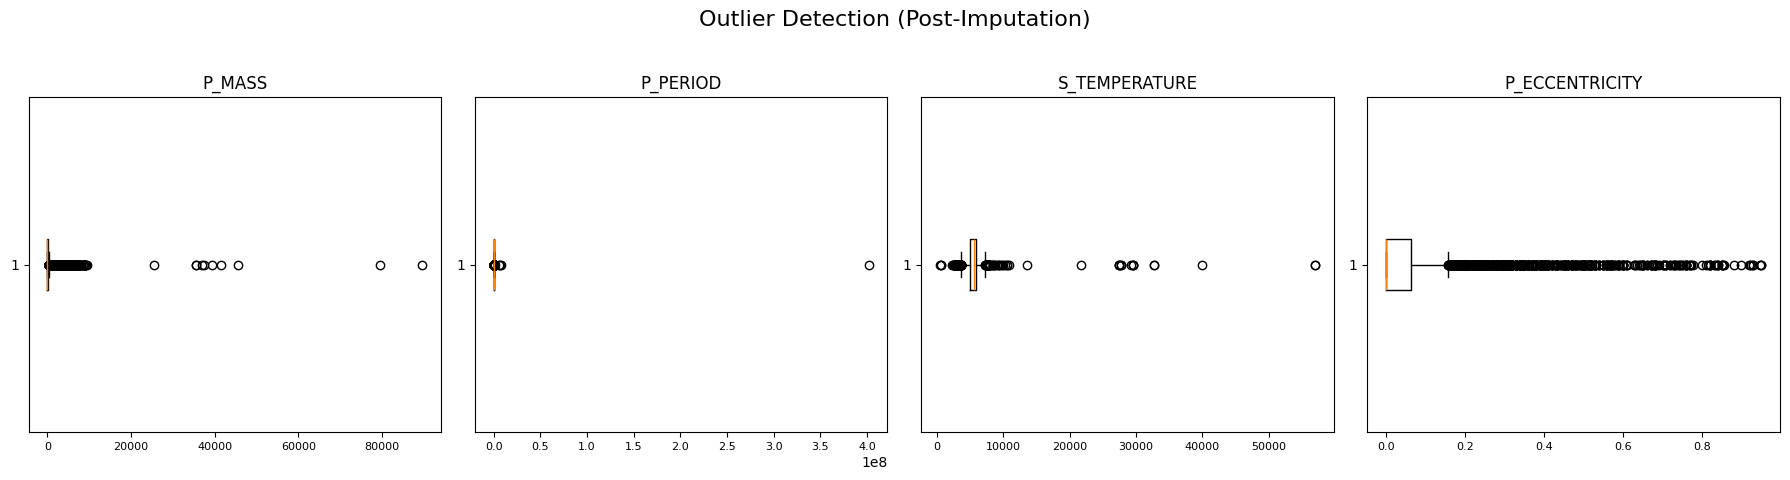

In [25]:
# Detect Outliers using Box Plot
plot_features = ['P_MASS', 'P_PERIOD', 'S_TEMPERATURE', 'P_ECCENTRICITY']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Outlier Detection (Post-Imputation)', fontsize=16)

for i, col in enumerate(plot_features):
    axes[i].boxplot(exoplanet_df[col], vert=False)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', labelsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()

In [26]:
# Handle Outliers 
for col in numerical_cols:
    # Calculate the stable 25th and 75th percentiles from the fully imputed data
    lower_bound = exoplanet_df[col].quantile(0.25)
    upper_bound = exoplanet_df[col].quantile(0.75)
    
    # Apply clipping (Winsorization)
    exoplanet_df[col] = exoplanet_df[col].clip(lower_bound, upper_bound)

In [27]:
# Impute missing values for categorical columns using most frequent strategy
mode_imputer = SimpleImputer(strategy='most_frequent')

# Fit and transform the data
exoplanet_df[categorical_cols] = mode_imputer.fit_transform(exoplanet_df[categorical_cols])

# Verification
print(f"Nulls remaining in categorical columns: {exoplanet_df[categorical_cols].isnull().sum().sum()}")

Nulls remaining in categorical columns: 216


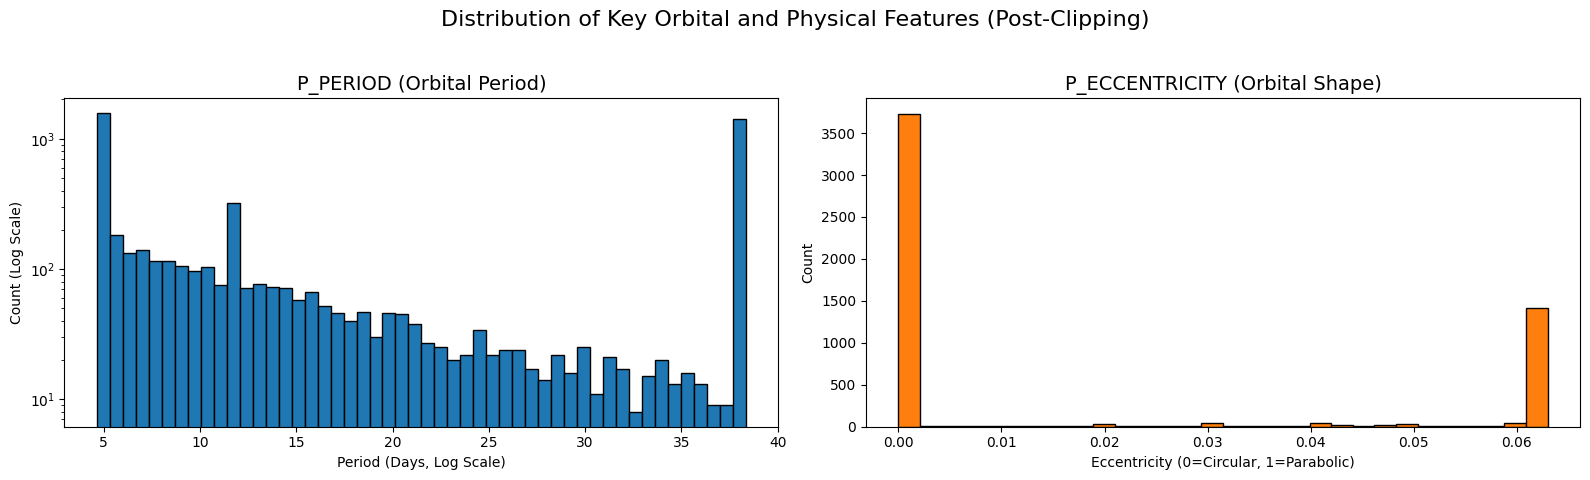

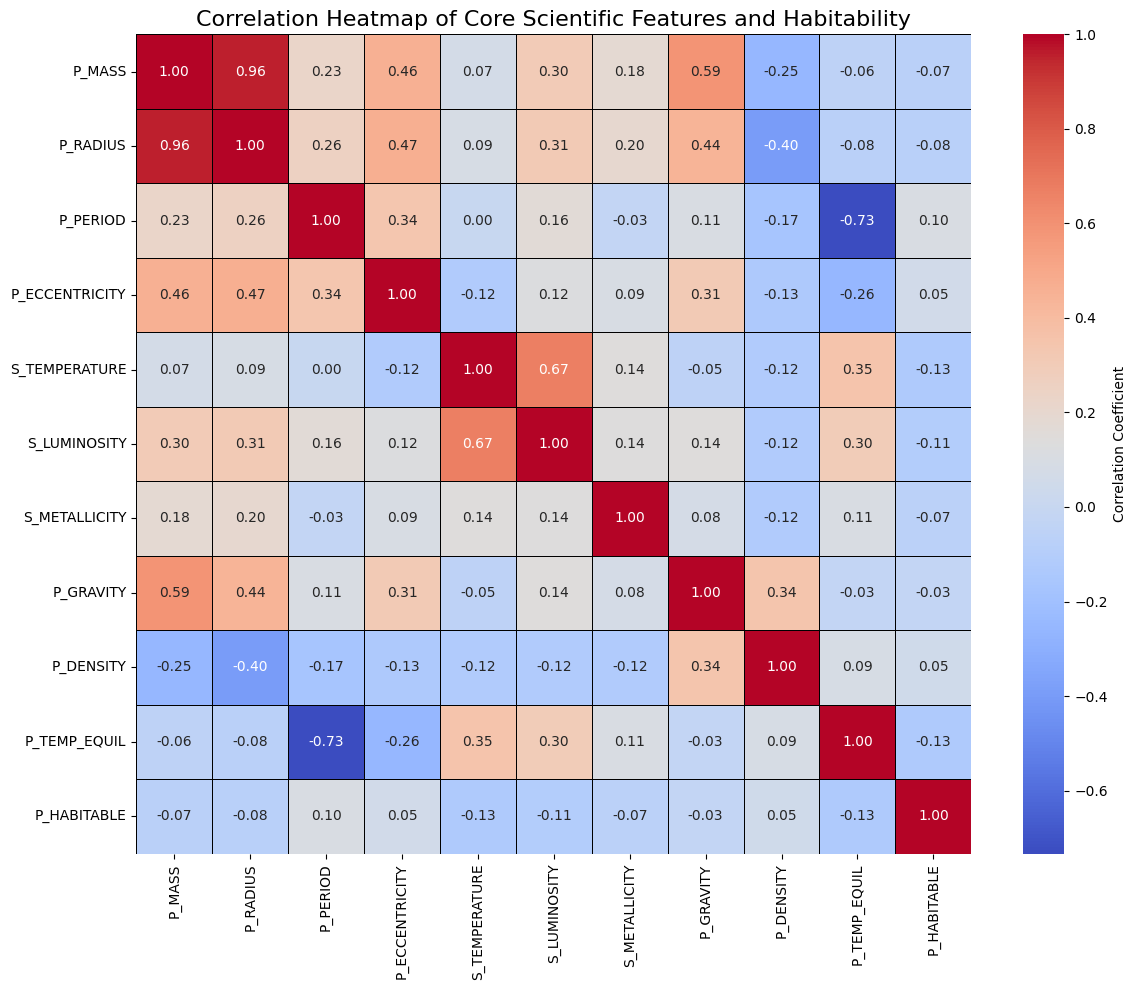

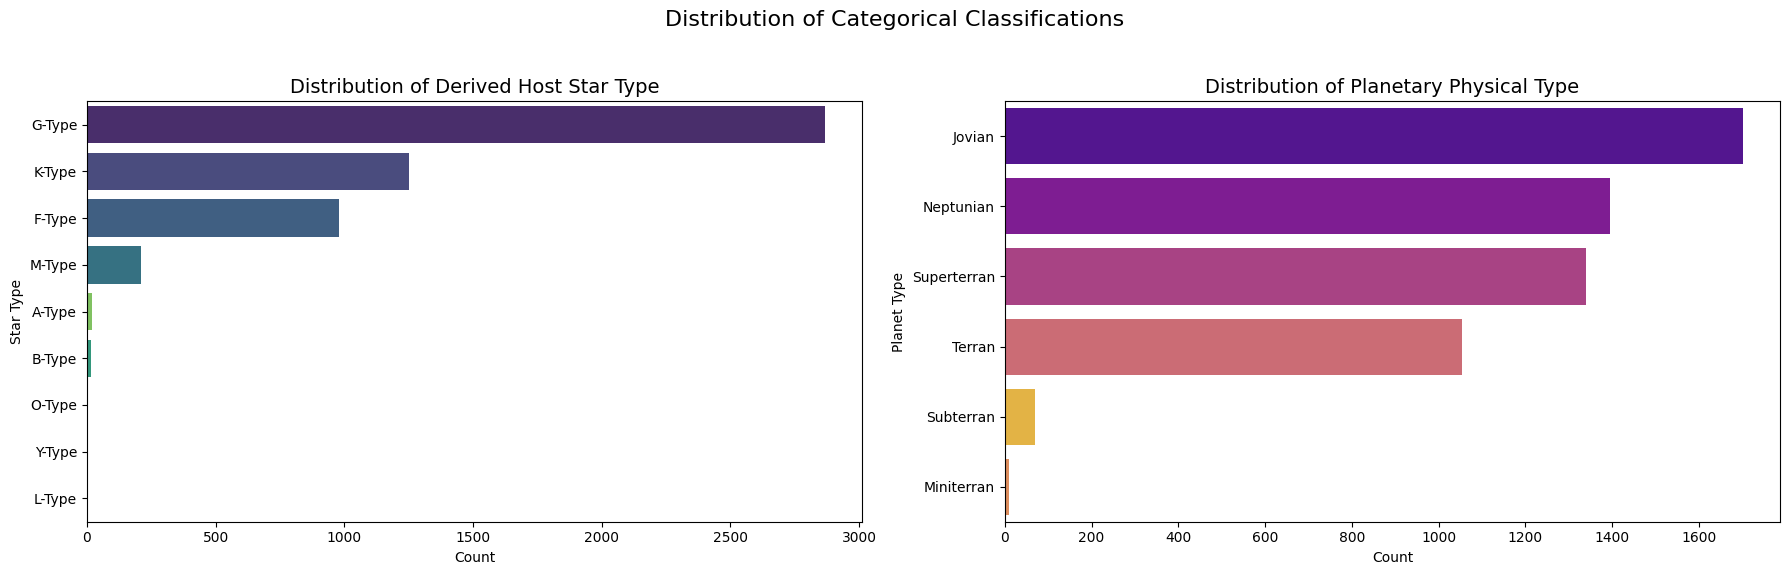

In [28]:
# Visualization: Plotting the Final Cleaned Data

# Define Core Features for Analysis (must match existing columns after cleaning)
numerical_core = ['P_MASS', 'P_RADIUS', 'P_PERIOD', 'P_ECCENTRICITY', 
                  'S_TEMPERATURE', 'S_LUMINOSITY', 'S_METALLICITY', 
                  'P_GRAVITY', 'P_DENSITY', 'P_TEMP_EQUIL', 'P_HABITABLE']

# Plot 1: Histograms for Key Numerical Distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribution of Key Orbital and Physical Features (Post-Clipping)', fontsize=16)

# P_PERIOD Distribution 
axes[0].hist(exoplanet_df['P_PERIOD'], bins=50, color='#1f77b4', edgecolor='black', log=True)
axes[0].set_title('P_PERIOD (Orbital Period)', fontsize=14)
axes[0].set_xlabel('Period (Days, Log Scale)')
axes[0].set_ylabel('Count (Log Scale)')

# P_ECCENTRICITY Distribution
axes[1].hist(exoplanet_df['P_ECCENTRICITY'], bins=30, color='#ff7f0e', edgecolor='black')
axes[1].set_title('P_ECCENTRICITY (Orbital Shape)', fontsize=14)
axes[1].set_xlabel('Eccentricity (0=Circular, 1=Parabolic)')
axes[1].set_ylabel('Count')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()


# Plot 2: Correlation Heatmap for Core Features
plt.figure(figsize=(12, 10))
# Calculate the correlation matrix for the top scientific features plus the target
corr_matrix = exoplanet_df[numerical_core].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5, 
            linecolor='black')
plt.title('Correlation Heatmap of Core Scientific Features and Habitability', fontsize=16)
plt.tight_layout()
plt.show()
plt.close()


# Plot 3: Count Plots for Categorical Features
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Distribution of Categorical Classifications', fontsize=16)

# Derived_S_TYPE Distribution 
sns.countplot(y=exoplanet_df['Derived_S_TYPE'], hue=exoplanet_df['Derived_S_TYPE'], ax=axes[0], palette='viridis', order=exoplanet_df['Derived_S_TYPE'].value_counts().index, legend=False)
axes[0].set_title('Distribution of Derived Host Star Type', fontsize=14)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Star Type')

# P_TYPE Distribution
sns.countplot(y=exoplanet_df['P_TYPE'], hue=exoplanet_df['P_TYPE'], ax=axes[1], palette='plasma', order=exoplanet_df['P_TYPE'].value_counts().index, legend=False)
axes[1].set_title('Distribution of Planetary Physical Type', fontsize=14)
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Planet Type')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.close()